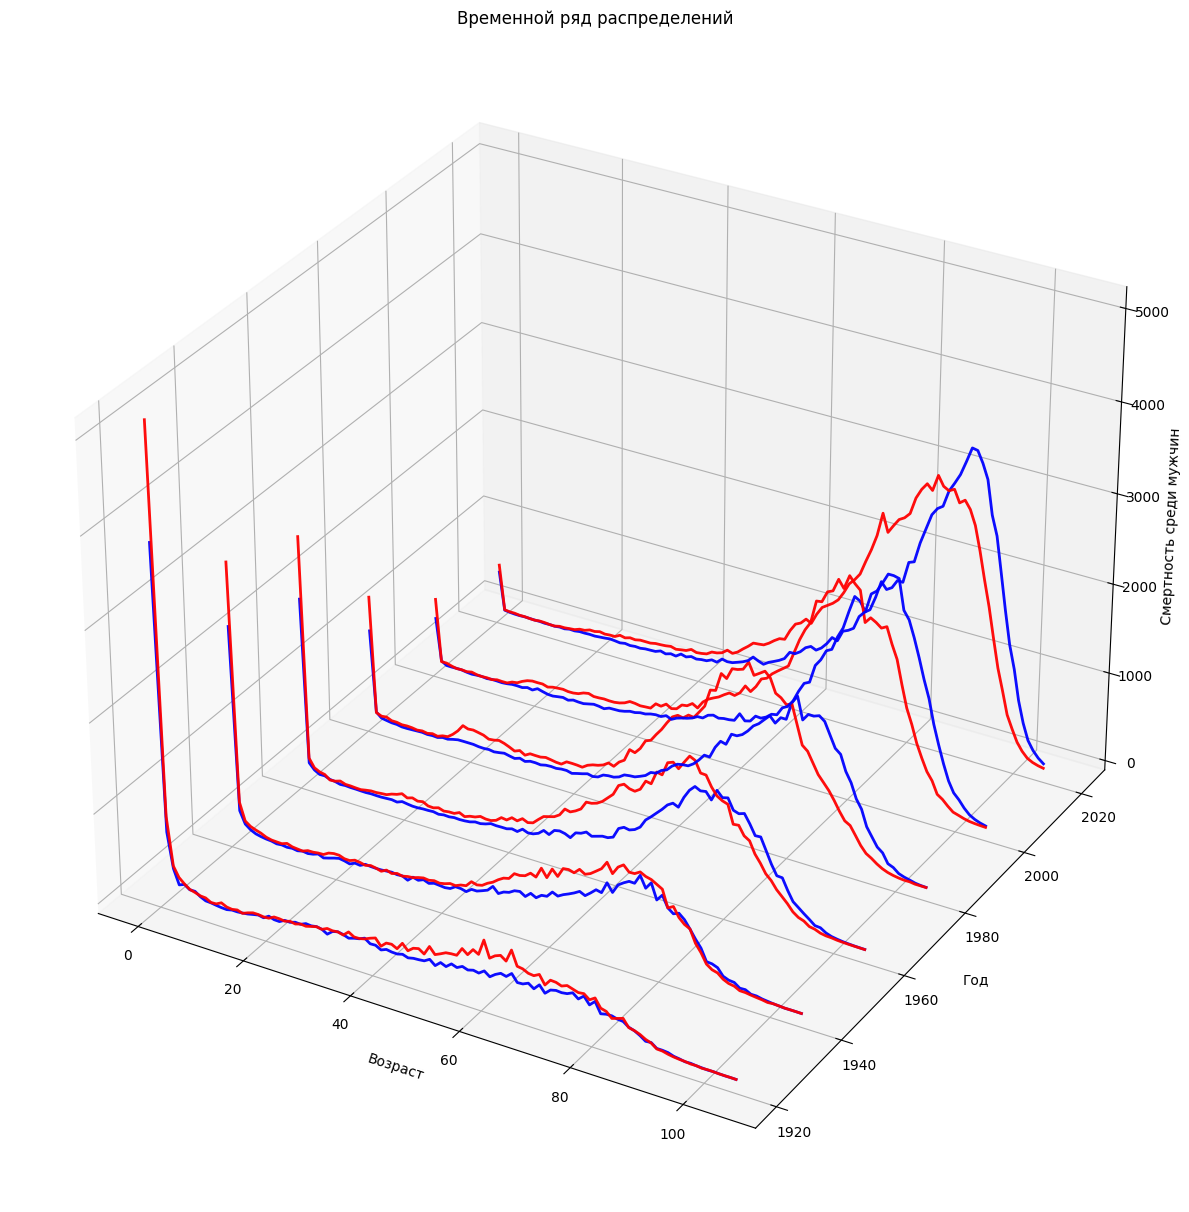

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Загрузка данных ---
# Красные линии — индивидуальные по годам
df_red = pd.read_csv('Australia_Deaths_without_header.txt', sep=r'\s+', header=None, names=['year', 'age', 'male_mortality', 'female_mortality', 'total_mortality'])
# Преобразуем year
df_red['year'] = df_red['year'].astype(int)

# Удаляем нечисловые возрасты (включая '110+')
df_red = df_red[pd.to_numeric(df_red['age'], errors='coerce').notna()]
df_red['age'] = df_red['age'].astype(int)

# Оставляем только 0–100
df_red = df_red[(df_red['age'] >= 0) & (df_red['age'] <= 105)]

# Уникальные годы (c 1921 по 2021 с шагом 25 лет)
years = np.arange(1921, 2022, 20)

# --- Построение графика ---
fig = plt.figure(figsize=(12, 14))
ax = fig.add_subplot(111, projection='3d')
#ax.set_box_aspect([1.7, 1, 1])  # [X, Y, Z] — относительные пропорции


file_name = 'Australia_Deaths_men_2021.txt'
# Открываем файл в режиме записи ('w') с использованием 'with'
with open(file_name, 'w', newline='', encoding='utf-8') as f:
    for index, row in df_red.iterrows():
        if row['year'] == 2021:
            line = '\t'.join(map(str, [row['age'], row['male_mortality']]))
            f.write(line + '\n')


# Красные линии — индивидуальные данные по годам
for yr in years:
    year_data = df_red[df_red['year'] == yr].sort_values('age')
    age_red = year_data['age'].values
    male_mortality_red = year_data['male_mortality'].values
    female_mortality_red = year_data['female_mortality'].values
    total_mortality_red = year_data['total_mortality'].values
    ax.plot(age_red, [yr] * len(age_red), male_mortality_red, color='blue', linewidth=2, alpha=0.95)
    ax.plot(age_red, [yr] * len(age_red), female_mortality_red, color='red', linewidth=2, alpha=0.95)
    #ax.plot(age_red, [yr] * len(age_red), total_mortality_red, color='green', linewidth=2, alpha=0.95)

# Оформление
ax.set_xlabel('Возраст')
ax.set_ylabel('Год')
ax.set_zlabel('Смертность среди мужчин')
ax.set_title('Временной ряд распределений')




# Убираем сетку для чистоты (опционально)
#ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')